# Principal Component Analysis on the UsArrests dataset

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Visualisation libraries.
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.impute import KNNImputer # You will need the scikit-learn version >= 0.22
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans


## 1. Load and preprocess the dataset

In [12]:
df =pd.read_csv('UsArrests.csv')
print(f'Shape (rows, coloumns): {df.shape}')
df.info()
df.head()

Shape (rows, coloumns): (50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [15]:
# Set the decimal precision
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Display statistical summary
print(df.describe())

       Murder  Assault  UrbanPop  Rape
count   50.00    50.00     50.00 50.00
mean     7.79   170.76     65.54 21.23
std      4.36    83.34     14.47  9.37
min      0.80    45.00     32.00  7.30
25%      4.08   109.00     54.50 15.07
50%      7.25   159.00     66.00 20.10
75%     11.25   249.00     77.75 26.18
max     17.40   337.00     91.00 46.00


## 2. Correlation Analysis

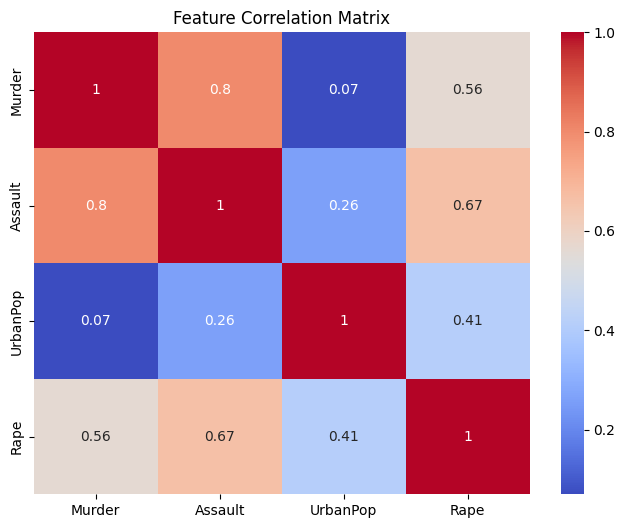

In [19]:
# Slice the feature columns, exclude 'city'
features = df.columns[1:]

'''# Pairwise scatter matrix
plt.figure(figsize=(10,10))
pd.plotting.scatter_matrix(df[features], figsize=(10,10), diagonal='kde')
plt.suptitle('Pairwise scatter matrix (UsArrests features)')
plt.show()'''

# Correlation matrix heatmap
corr_matrix = df[features].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax)
plt.title('Feature Correlation Matrix')
plt.show()

3. Interpretation

Murder and Assault (r ≈ 0.80)
→ Strong positive correlation.
States with high murder rates tend also to have high assault rates. This suggests a general violent crime trend across states.

Assault and Rape (r ≈ 0.67)
→ Moderately strong positive correlation.
High-assault states also report higher rape rates, reinforcing the idea that some states generally have higher violent crime rates across categories.

Murder and Rape (r ≈ 0.56)
→ Moderate positive correlation.
Indicates that states with more murders tend to have somewhat more rapes, but not as strongly as the Murder–Assault link.

UrbanPop with other variables (r ≈ 0.07–0.41)
→ Weak to moderate correlations.
Urbanization has only a weak relationship with murder and assault, and a slightly stronger one with rape. This suggests urbanization might contribute modestly to overall crime exposure but isn’t the main driver.

## 3. Standardize the variables
PCA requires comparable scaling, we will scale variables that are on different scales.

In [22]:
# n_components
nc = 2

# Create a scaled version of the feature data
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=nc)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results
pca_columns = [f'PC{i+1}' for i in range(nc)]
df_pca = pd.DataFrame(data=X_pca, columns=pca_columns)
df_pca.head()

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("\nExplained variance ratio by component:")
for i, (ev, cev) in enumerate(zip(explained, cum_explained), start=1):
    print(f"PC{i}: {ev:.4f}  | Cumulative: {cev:.4f}")


Explained variance ratio by component:
PC1: 0.6201  | Cumulative: 0.6201
PC2: 0.2474  | Cumulative: 0.8675


## 4. Biplot
Plot of the first 2 principal components

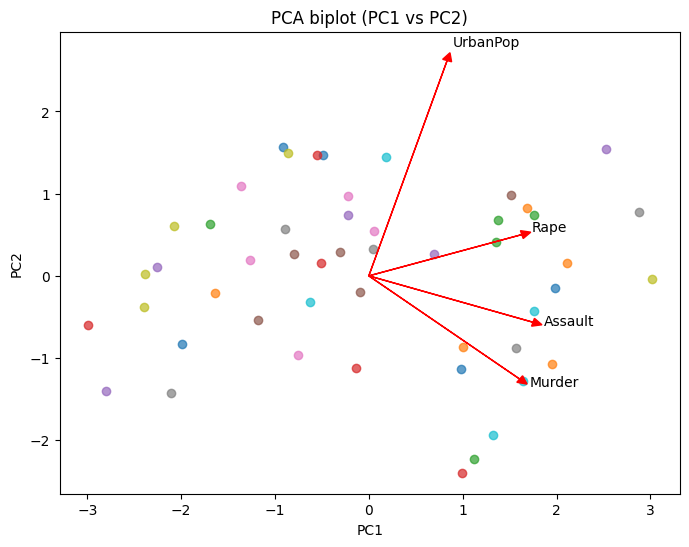

In [28]:
# Set up PCA biplot
loadings = pca.components_.T[:,:2]

# Plot PCA biplot
fig, ax = plt.subplots(figsize=(8,6))
if 'City' in df.columns:
    for spec in df['City'].unique():
        idx = df['City']==spec
        ax.scatter(X_pca[idx,0], X_pca[idx,1], label=spec, alpha=0.7)
else:
    ax.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)

# Plot loadings as arrows
for i, feat in enumerate(features):
    ax.arrow(0,0, loadings[i,0]*3, loadings[i,1]*3, head_width=0.1, head_length=0.1, color='red')
    ax.text(loadings[i,0]*3.2, loadings[i,1]*3.2, feat)

# Labeling
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA biplot (PC1 vs PC2)')
plt.show()

## Cluster techniques